# Piecewise linear function

## Upper Envelope

$$
U(x) = \max \{ f_1(x), f_2(x), f_3(x) \}
$$

In [24]:
%pip install numpy
%pip install matplotlib
%pip install itertools

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools
Note: you may need to restart the kernel to use updated packages.


In [25]:
import sys
sys.path.append('ipynb/location/packages')

In [26]:
from packages.Point import FunctionPlotter
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

In [27]:
def f1(x):
    return x

def f2(x):
    return -x + 4

def f3(x):
    return x+3

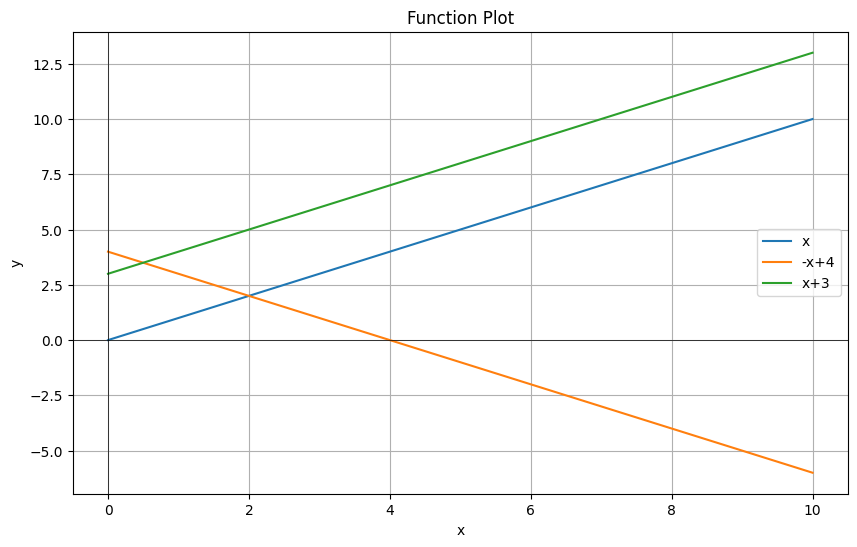

In [28]:
plotter = FunctionPlotter(0, 10, 100)
plotter.add_function(f1, "x")
plotter.add_function(f2, "-x+4")
plotter.add_function(f3, "x+3")
plotter.plot()

$$
U_{\text{(Function Plot)}}(x) = \max \{x, -x+4, x+3 \}
$$

In [29]:
lines = [
    lambda x: x,
    lambda x: -x + 4,
    lambda x: x + 3
]

def upper_envelope(x):
    return max(f(x) for f in lines)

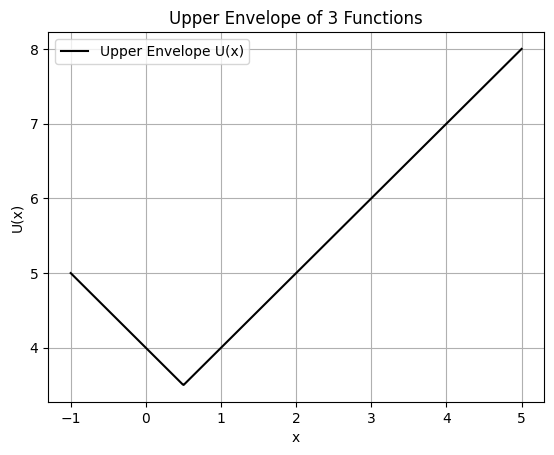

In [30]:
x_vals = np.linspace(-1, 5, 500)
y_vals = [upper_envelope(x) for x in x_vals]

plt.plot(x_vals, y_vals, label='Upper Envelope U(x)', color='black')
plt.legend()
plt.grid(True)
plt.title("Upper Envelope of 3 Functions")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.show()

In [31]:
def intersect(f1, f2):
    a1 = f1(1) - f1(0)
    b1 = f1(0)
    a2 = f2(1) - f2(0)
    b2 = f2(0)
    if a1 == a2:
        return None
    return (b2 - b1) / (a1 - a2)

xs = []
for f1, f2 in combinations(lines, 2):
    x = intersect(f1, f2)
    if x is not None:
        xs.append(x)

# You may want to restrict the domain or extend range
candidates = xs + [-100, 100]

min_val = float('inf')
min_x = None
for x in candidates:
    val = upper_envelope(x)
    if val < min_val:
        min_val = val
        min_x = x

print(f"Minimum of upper envelope is {min_val} at x = {min_x}")

Minimum of upper envelope is 3.5 at x = 0.5


## Package testing

In [32]:
from packages.Point import LocalMinima

In [33]:
eg = LocalMinima()

eg.add_line(lambda x: x)
eg.add_line(lambda x: -x+4)
eg.add_line(lambda x: x+3)

min_val, min_x = eg.showVal(-100, 100)
print(min_x)
print(min_val)

0.5
3.5
